# Task 4: Anomaly Detection — Flagging Potential Emissions Underreporting

**Project:** Emissions from Above  
**Dataset:** US Power Plant Satellite Imagery Dataset (USPPDS) + EPA eGRID 2014

---

## Overview

Train on facilities with **verified emissions records**. Apply the trained fusion model  
(from Task 3) to plants with sparse, missing, or historically questionable reporting.  
**Large residuals** (predicted >> reported) flag candidates for regulatory follow-up.

The pipeline implements:
1. **Residual-based anomaly scoring** from the Task 3 fusion model
2. **Isolation Forest** on image embeddings (unsupervised)
3. **One-Class SVM** on tabular features (unsupervised)
4. **Ensemble scoring** combining all signals into a ranked watchlist
5. **Monte Carlo Dropout** for predictive uncertainty quantification

> **Goal:** Produce a ranked facility watchlist with anomaly scores, uncertainty estimates,  
> and visualizations to support regulatory prioritisation.


## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# rasterio is optional on Windows; tifffile is the lightweight fallback
try:
    import rasterio
    _USE_RASTERIO = True
except ImportError:
    import tifffile
    _USE_RASTERIO = False

def read_tif_bands(path, n_bands=3):
    if _USE_RASTERIO:
        with rasterio.open(path) as src:
            return src.read()[:n_bands].astype('float32')
    arr = tifffile.imread(str(path)).astype('float32')
    if arr.ndim == 2:
        arr = arr[None]                          # (1, H, W)
    elif arr.ndim == 3 and arr.shape[2] <= 20:  # (H, W, bands) -> (bands, H, W)
        arr = arr.transpose(2, 0, 1)
    return arr[:n_bands]

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_recall_curve, roc_curve)
from sklearn.impute import SimpleImputer
import joblib
import scipy.stats as stats

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f"Image reader: {'rasterio' if _USE_RASTERIO else 'tifffile'}")


Device: cuda
Image reader: tifffile


## 2. Configuration

In [2]:
import sys
import os
import time

# Local paths — no Google Drive mount needed
PROJECT_ROOT = Path.cwd()   # VS Code Jupyter sets cwd to the notebook directory
DATA_ROOT    = PROJECT_ROOT / 'data'
LANDSAT_DIR  = DATA_ROOT / 'uspp_landsat'
EGRID_XLSX   = DATA_ROOT / 'eGRID2014_Data_v2_US_EPA_with_imagery_list_for_power_plants.xlsx'
OUTPUT_DIR   = PROJECT_ROOT / 'outputs' / 'task4_anomaly_detection'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Paths to artifacts from Task 3
TASK3_DIR      = PROJECT_ROOT / 'outputs' / 'task3_regression'
FUSION_CKPT    = TASK3_DIR / 'fusion_model_best.pth'
GBT_MODEL_PATH = TASK3_DIR / 'gbt_model.pkl'

# Anomaly thresholds
RESIDUAL_ZSCORE_THRESH = 2.5
ISO_CONTAMINATION      = 0.05
MC_DROPOUT_PASSES      = 50

TAB_FEATURES = ['NAMEPCAP', 'CAPFAC', 'PLNGENAN', 'HEATRT', 'PLHTIAN']
EMBED_DIM    = 256
BATCH_SIZE   = 32

print(f'Project root : {PROJECT_ROOT}')
print(f'Data exists  : {DATA_ROOT.exists()}')
print(f'EGRID exists : {EGRID_XLSX.exists()}')
print(f'Landsat dir  : {LANDSAT_DIR.exists()}')
print(f'Fusion ckpt  : {FUSION_CKPT.exists()}')


Project root : c:\Users\mateo\OneDrive - The University of Chicago\Documents\Data Science Folder\MLII Final Project\ML2FP
Data exists  : True
EGRID exists : True
Landsat dir  : True
Fusion ckpt  : True


## 3. Load eGRID & Flag "Suspicious" Records

In [3]:
egrid_raw = pd.read_excel(EGRID_XLSX, sheet_name="PLNT14", header=1)

relevant_cols = ['SEQPLT14', 'PNAME', 'PSTATABB', 'CNTYNAME', 'PLPRMFL','PLFUELCT',
                 'PLCO2AN', 'PLCO2RTA', 'LAT', 'LON'] + TAB_FEATURES
available = [c for c in relevant_cols if c in egrid_raw.columns]
egrid = egrid_raw[available].copy()

img_col = [c for c in egrid_raw.columns if 'imagery' in c.lower() or 'status' in c.lower()]
if img_col:
    egrid['imagery_status'] = egrid_raw[img_col[0]]

egrid = egrid.dropna(subset=['SEQPLT14', 'PLFUELCT'])
egrid['SEQPLT14'] = egrid['SEQPLT14'].astype(int)
egrid['PLFUELCT'] = egrid['PLFUELCT'].str.strip().str.upper()

# CO2 intensity
rate_col = 'PLCO2RTA' if 'PLCO2RTA' in egrid.columns else None
if rate_col:
    egrid['co2_intensity'] = pd.to_numeric(egrid[rate_col], errors='coerce')
else:
    egrid['co2_intensity'] = (pd.to_numeric(egrid.get('PLCO2AN', np.nan), errors='coerce') * 2000 /
                              pd.to_numeric(egrid.get('PLNGENAN', np.nan), errors='coerce').replace(0, np.nan))

egrid['target'] = np.log1p(egrid['co2_intensity'].clip(lower=0))

# ── Verification status ──────────────────────────────────────────────────────
# "Verified" = has a valid, non-zero CO2 intensity on record
# "Suspicious" = missing, zero, or implausibly low CO2 for a fossil fuel plant

FOSSIL_FUELS = {'COAL', 'GAS', 'OIL', 'OFSL'}

def assign_verification_status(row):
    intensity = row['co2_intensity']
    fuel      = row['PLFUELCT']
    if pd.isna(intensity) or intensity == 0:
        if fuel in FOSSIL_FUELS:
            return 'suspicious'      # Fossil fuel with no reported emissions
        return 'missing'
    elif intensity < 50 and fuel in FOSSIL_FUELS:
        return 'suspicious'          # Implausibly low for fossil fuel
    return 'verified'

egrid['verification_status'] = egrid.apply(assign_verification_status, axis=1)

status_counts = egrid['verification_status'].value_counts()
print(f"Verification status:\n{status_counts}")


Verification status:
verification_status
missing       4768
verified      2946
suspicious     747
Name: count, dtype: int64


In [4]:
# Image paths
def build_landsat_path(row, base_dir):
    return base_dir / f"ls8_{int(row['SEQPLT14'])}_{str(row.get('PSTATABB','XX')).strip().upper()}_{str(row.get('PLPRMFL','UNKN')).strip().upper()}.tif"

egrid['img_path']   = egrid.apply(build_landsat_path, axis=1, base_dir=LANDSAT_DIR)
egrid['img_exists'] = egrid['img_path'].apply(lambda p: p.exists())
egrid = egrid[egrid['img_exists']].reset_index(drop=True)

verified_df   = egrid[egrid['verification_status'] == 'verified'].reset_index(drop=True)
suspicious_df = egrid[egrid['verification_status'] == 'suspicious'].reset_index(drop=True)
all_df        = egrid.copy()

print(f"Verified plants (with imagery): {len(verified_df)}")
print(f"Suspicious plants (with imagery): {len(suspicious_df)}")


Verified plants (with imagery): 1777
Suspicious plants (with imagery): 320


## 4. Reload Trained Fusion Model from Task 3

In [5]:
le = LabelEncoder()
le.fit(egrid['PLFUELCT'])
egrid['fuel_enc'] = le.transform(egrid['PLFUELCT'])
verified_df['fuel_enc']   = le.transform(verified_df['PLFUELCT'])
suspicious_df['fuel_enc'] = le.transform(suspicious_df['PLFUELCT'])
all_df['fuel_enc']        = le.transform(all_df['PLFUELCT'])

tab_cols_mm = [c for c in TAB_FEATURES if c in egrid.columns] + ['fuel_enc']


class LateFusionRegressor(nn.Module):
    """Exact same architecture as Task 3 — must match saved checkpoint."""
    def __init__(self, n_img_channels=3, n_tab_features=6, embed_dim=128, dropout=0.4):
        super().__init__()
        backbone = models.resnet18(weights=None)
        in_feat  = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.img_branch = backbone
        self.img_proj   = nn.Sequential(nn.Linear(in_feat, embed_dim), nn.ReLU(), nn.Dropout(dropout))
        self.tab_branch = nn.Sequential(
            nn.Linear(n_tab_features, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, embed_dim), nn.ReLU())
        self.head = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(embed_dim, 1))

    def forward(self, img, tab):
        img_emb = self.img_proj(self.img_branch(img))
        tab_emb = self.tab_branch(tab)
        return self.head(torch.cat([img_emb, tab_emb], dim=1))

    def get_embedding(self, img, tab):
        #"""Return fused embedding (before final linear) for anomaly detection."""
        img_emb = self.img_proj(self.img_branch(img))
        tab_emb = self.tab_branch(tab)
        fused   = torch.cat([img_emb, tab_emb], dim=1)
        # Return everything up to the last linear layer
        return self.head[:-1](fused)


if FUSION_CKPT.exists():
    fusion_model = LateFusionRegressor(
        n_img_channels=3, n_tab_features=len(tab_cols_mm),
        embed_dim=EMBED_DIM, dropout=0.4).to(device)
    fusion_model.load_state_dict(torch.load(FUSION_CKPT, map_location=device))
    print("Fusion model loaded from Task 3 checkpoint.")
else:
    print(f"WARNING: Checkpoint not found at {FUSION_CKPT}")
    print("Run Task 3 notebook first to train and save the fusion model.")
    print("Creating untrained model for demonstration...")
    fusion_model = LateFusionRegressor(
        n_img_channels=3, n_tab_features=len(tab_cols_mm),
        embed_dim=EMBED_DIM, dropout=0.4).to(device)

Fusion model loaded from Task 3 checkpoint.


## 5. Dataset & Inference Utilities

In [6]:
from tqdm import tqdm


def build_image_cache(df, transform, n_bands=3):
    """Pre-load every satellite image into RAM once, keyed by Path."""
    cache = {}
    for path in tqdm(df['img_path'].unique(), desc='Caching images'):
        try:
            bands = read_tif_bands(path, n_bands)
            for c in range(bands.shape[0]):
                ch = bands[c]; mn, mx = ch.min(), ch.max()
                bands[c] = (ch - mn) / (mx - mn + 1e-8)
            img_t = torch.from_numpy(bands)
            if transform:
                img_t = transform(img_t)
            cache[path] = img_t
        except Exception:
            cache[path] = torch.zeros(n_bands, 64, 64)
    return cache


class InferenceDataset(Dataset):
    def __init__(self, df, tab_cols, scaler, image_cache, n_bands=3):
        self.df = df.reset_index(drop=True)
        self.tab_cols = tab_cols
        self.n_bands = n_bands
        self.image_cache = image_cache
        tab_data = self.df[tab_cols].fillna(self.df[tab_cols].median()).values.astype('float32')
        self.tab_data = scaler.transform(tab_data)

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_t = self.image_cache.get(row['img_path'], torch.zeros(self.n_bands, 64, 64))
        tab_t = torch.from_numpy(self.tab_data[idx])
        target = torch.tensor(
            row['target'] if not pd.isna(row['target']) else -999.0,
            dtype=torch.float32)
        return img_t, tab_t, target


val_transform = T.Compose([T.Resize((64, 64), antialias=True)])

# Fit scaler on verified (training) data
scaler_mm = StandardScaler()
imp = SimpleImputer(strategy='median')
imp.fit(verified_df[tab_cols_mm].values)
scaler_mm.fit(imp.transform(verified_df[tab_cols_mm].values))

# Build image cache once — all reads happen here, DataLoader workers see only tensors
print('Building image cache for all plants...')
image_cache = build_image_cache(all_df, val_transform, n_bands=3)
print(f'Cached {len(image_cache)} unique images.')

verified_ds   = InferenceDataset(verified_df,   tab_cols_mm, scaler_mm, image_cache)
suspicious_ds = InferenceDataset(suspicious_df, tab_cols_mm, scaler_mm, image_cache)
all_ds        = InferenceDataset(all_df,        tab_cols_mm, scaler_mm, image_cache)

# num_workers=0: Windows multiprocessing with DataLoader is unreliable;
# since images are already in RAM the zero-worker path is fast enough.
verified_loader   = DataLoader(verified_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
suspicious_loader = DataLoader(suspicious_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
all_loader        = DataLoader(all_ds,        batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


Building image cache for all plants...


Caching images: 100%|██████████| 4435/4435 [00:18<00:00, 234.04it/s]

Cached 4435 unique images.


## 6. MC Dropout — Predictive Uncertainty

In [7]:
def enable_dropout(model):
    #"""Keep dropout active during inference for MC Dropout.""""
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.train()


@torch.no_grad()
def mc_dropout_predict(model, loader, n_passes=MC_DROPOUT_PASSES):
    """
    Run n_passes stochastic forward passes.
    Returns: mean predictions, std (epistemic uncertainty), embeddings.
    """
    model.eval()
    enable_dropout(model)   # Re-enable dropout

    all_pass_preds = []
    embeddings_list = []

    for _ in range(n_passes):
        pass_preds = []
        for imgs, tabs, targets in loader:
            imgs, tabs = imgs.to(device), tabs.to(device)
            preds = model(imgs, tabs).squeeze(1).cpu().numpy()
            pass_preds.extend(preds)
        all_pass_preds.append(pass_preds)

    # Embeddings: single deterministic pass
    model.eval()
    for imgs, tabs, targets in loader:
        imgs, tabs = imgs.to(device), tabs.to(device)
        embs = model.get_embedding(imgs, tabs).cpu().numpy()
        embeddings_list.append(embs)

    all_pass_preds = np.array(all_pass_preds)  # (n_passes, N)
    mean_preds  = all_pass_preds.mean(axis=0)
    std_preds   = all_pass_preds.std(axis=0)
    embeddings  = np.vstack(embeddings_list)

    return mean_preds, std_preds, embeddings


print("Running MC Dropout inference on all plants...")
mean_preds, std_preds, embeddings = mc_dropout_predict(fusion_model, all_loader)

all_df['pred_log_intensity'] = mean_preds
all_df['pred_uncertainty']   = std_preds
all_df['pred_intensity']     = np.expm1(np.clip(mean_preds, 0, 20))   # back-transform


Running MC Dropout inference on all plants...


## 7. Residual-Based Anomaly Scoring

In [8]:
# Compute residual: predicted - reported (in log space)
# Positive residual → model predicts higher emissions than reported → suspicious
all_df['residual'] = all_df['pred_log_intensity'] - all_df['target']

# Fit residual distribution on verified plants only
verified_mask = all_df['verification_status'] == 'verified'
verified_residuals = all_df.loc[verified_mask, 'residual'].dropna()

res_mean = verified_residuals.mean()
res_std  = verified_residuals.std()

all_df['residual_zscore'] = (all_df['residual'] - res_mean) / res_std

print(f"Residual distribution (verified plants): mean={res_mean:.3f}, std={res_std:.3f}")
print(f"\nFlagged by residual Z-score > {RESIDUAL_ZSCORE_THRESH}:")
flagged_res = all_df[all_df['residual_zscore'] > RESIDUAL_ZSCORE_THRESH]
print(f"  {len(flagged_res)} plants ({len(flagged_res)/len(all_df):.1%} of total)")


Residual distribution (verified plants): mean=-1.744, std=2.126

Flagged by residual Z-score > 2.5:
  71 plants (1.6% of total)


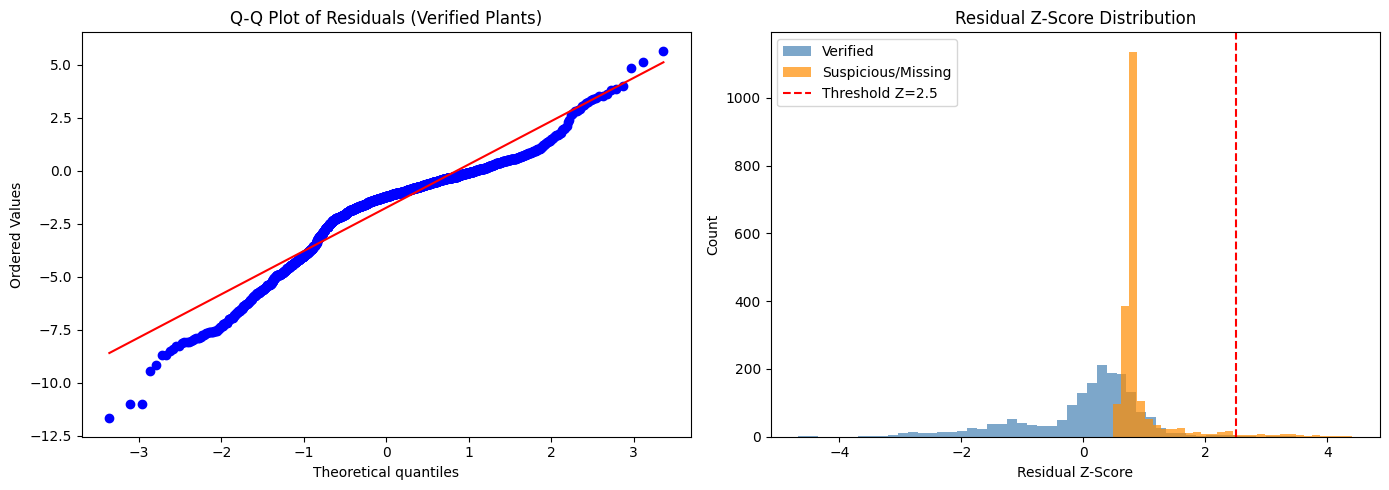

In [9]:
# Residual distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Q-Q plot of residuals vs. normal
stats.probplot(verified_residuals, plot=axes[0])
axes[0].set_title("Q-Q Plot of Residuals (Verified Plants)")

# Residual histogram with flagging threshold
axes[1].hist(all_df.loc[verified_mask, 'residual_zscore'].dropna(),
             bins=50, color='steelblue', alpha=0.7, label='Verified')
axes[1].hist(all_df.loc[~verified_mask, 'residual_zscore'].dropna(),
             bins=30, color='darkorange', alpha=0.7, label='Suspicious/Missing')
axes[1].axvline(RESIDUAL_ZSCORE_THRESH, color='red', linestyle='--',
                label=f'Threshold Z={RESIDUAL_ZSCORE_THRESH}')
axes[1].set_xlabel('Residual Z-Score'); axes[1].set_ylabel('Count')
axes[1].set_title('Residual Z-Score Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'residual_distribution.png', dpi=150)
plt.show()


## 8. Unsupervised Anomaly Detection — Isolation Forest

In [10]:
# Train Isolation Forest on embeddings of VERIFIED plants only
# Then score ALL plants — anomalies will have high anomaly scores

pca_for_iso = PCA(n_components=min(32, embeddings.shape[1]), random_state=SEED)
embs_pca = pca_for_iso.fit_transform(embeddings)

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=ISO_CONTAMINATION,
    random_state=SEED,
    n_jobs=-1
)
iso_forest.fit(embs_pca[verified_mask.values])   # Train only on verified

# Score all plants (more negative = more anomalous)
iso_scores = iso_forest.decision_function(embs_pca)
iso_pred   = iso_forest.predict(embs_pca)  # -1 = anomaly, 1 = normal

all_df['iso_score']      = iso_scores
all_df['iso_anomaly']    = (iso_pred == -1).astype(int)

print(f"Isolation Forest anomalies: {all_df['iso_anomaly'].sum()} "
      f"({all_df['iso_anomaly'].mean():.1%} of all plants)")
print(f"  Among suspicious plants: "
      f"{all_df.loc[~verified_mask,'iso_anomaly'].mean():.1%}")


Isolation Forest anomalies: 98 (2.2% of all plants)
  Among suspicious plants: 0.3%


## 9. One-Class SVM on Tabular Features

In [11]:
tab_data_scaled = scaler_mm.transform(
    imp.transform(all_df[tab_cols_mm].values)
)

oc_svm = OneClassSVM(kernel='rbf', nu=ISO_CONTAMINATION, gamma='scale')
oc_svm.fit(tab_data_scaled[verified_mask.values])

svm_scores = oc_svm.decision_function(tab_data_scaled)  # higher = more normal
svm_pred   = oc_svm.predict(tab_data_scaled)            # -1 = anomaly

all_df['svm_score']   = svm_scores
all_df['svm_anomaly'] = (svm_pred == -1).astype(int)

print(f"One-Class SVM anomalies: {all_df['svm_anomaly'].sum()} "
      f"({all_df['svm_anomaly'].mean():.1%} of all plants)")


One-Class SVM anomalies: 1334 (30.1% of all plants)


## 10. Ensemble Anomaly Score & Ranked Watchlist

In [12]:
# Normalise each signal to [0, 1] (higher = more anomalous)
def minmax_normalize(x):
    mn, mx = x.min(), x.max()
    return (x - mn) / (mx - mn + 1e-8)

all_df['residual_score_norm'] = minmax_normalize(all_df['residual_zscore'].fillna(0).clip(lower=0))
all_df['iso_score_norm']      = minmax_normalize(-all_df['iso_score'])   # more negative = worse
all_df['svm_score_norm']      = minmax_normalize(-all_df['svm_score'])
all_df['uncertainty_norm']    = minmax_normalize(all_df['pred_uncertainty'])

# Weighted ensemble (tune weights based on validation performance)
W_RESIDUAL    = 0.40
W_ISO         = 0.25
W_SVM         = 0.20
W_UNCERTAINTY = 0.15

all_df['ensemble_score'] = (
    W_RESIDUAL    * all_df['residual_score_norm'] +
    W_ISO         * all_df['iso_score_norm']      +
    W_SVM         * all_df['svm_score_norm']      +
    W_UNCERTAINTY * all_df['uncertainty_norm']
)

print("Ensemble weights:")
print(f"  Residual Z-score:  {W_RESIDUAL:.0%}")
print(f"  Isolation Forest:  {W_ISO:.0%}")
print(f"  One-Class SVM:     {W_SVM:.0%}")
print(f"  MC Uncertainty:    {W_UNCERTAINTY:.0%}")


Ensemble weights:
  Residual Z-score:  40%
  Isolation Forest:  25%
  One-Class SVM:     20%
  MC Uncertainty:    15%


In [13]:
# ── Ranked Watchlist ─────────────────────────────────────────────────────────
watchlist_cols = ['SEQPLT14', 'PNAME', 'PSTATABB', 'PLFUELCT',
                  'co2_intensity', 'pred_intensity', 'residual_zscore',
                  'pred_uncertainty', 'ensemble_score', 'verification_status']
watchlist_cols = [c for c in watchlist_cols if c in all_df.columns]

watchlist = (all_df[watchlist_cols]
             .sort_values('ensemble_score', ascending=False)
             .reset_index(drop=True))
watchlist.index += 1   # 1-based rank
watchlist.index.name = 'rank'

print("\n=== TOP 20 FLAGGED FACILITIES ===")
print(watchlist.head(20).to_string())
watchlist.to_csv(OUTPUT_DIR / 'anomaly_watchlist.csv')
print("\nWatchlist saved to:", OUTPUT_DIR / 'anomaly_watchlist.csv')



=== TOP 20 FLAGGED FACILITIES ===
      SEQPLT14                          PNAME PSTATABB PLFUELCT  co2_intensity  pred_intensity  residual_zscore  pred_uncertainty  ensemble_score verification_status
rank                                                                                                                                                                 
1         4415                     New Prague       MN      GAS          0.000     2055.609863         4.409367          1.042514        0.627245          suspicious
2         1477       SF Southeast Cogen Plant       CA  BIOMASS          0.000     1187.272095         4.151289          1.020136        0.572952             missing
3         2255                BJ Gas Recovery       GA  BIOMASS          0.000     1281.608887         4.187230          1.012363        0.571497             missing
4         3412            Cox Waste to Energy       KY  BIOMASS          0.000     1212.149902         4.161037          1.037697      

## 11. Visualizations

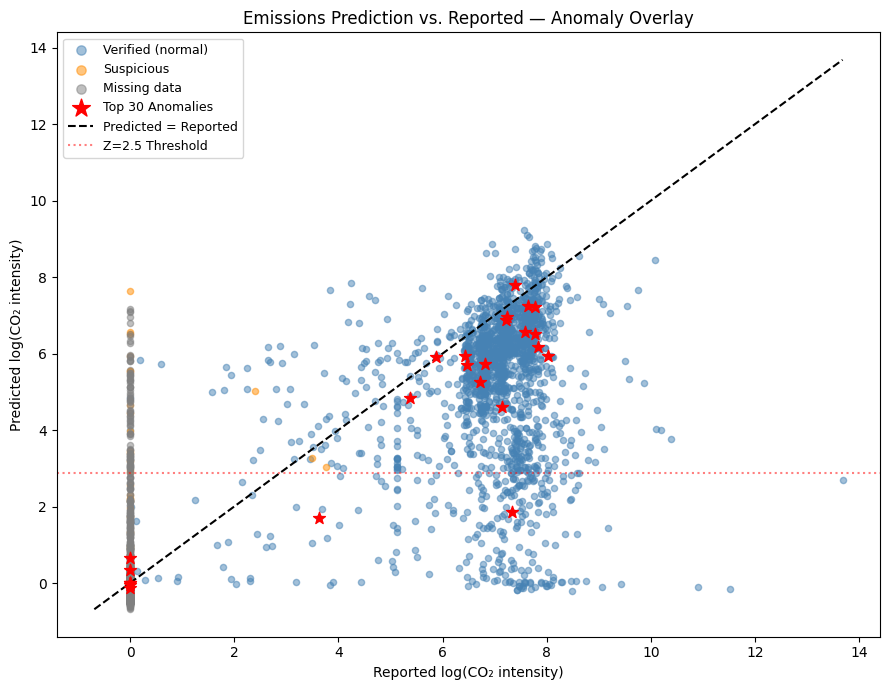

In [14]:
# ── Scatter: Predicted vs Reported (highlighting anomalies) ─────────────────
fig, ax = plt.subplots(figsize=(9, 7))

for status, color, label in [
    ('verified',   'steelblue',   'Verified (normal)'),
    ('suspicious', 'darkorange',  'Suspicious'),
    ('missing',    'gray',        'Missing data'),
]:
    mask_s = all_df['verification_status'] == status
    ax.scatter(all_df.loc[mask_s, 'target'],
               all_df.loc[mask_s, 'pred_log_intensity'],
               c=color, alpha=0.5, s=20, label=label)

# Overlay top anomalies
top_anom = watchlist.head(30)
ax.scatter(all_df.loc[top_anom.index - 1, 'target'],
           all_df.loc[top_anom.index - 1, 'pred_log_intensity'],
           c='red', s=80, marker='*', zorder=5, label='Top 30 Anomalies')

# Perfect-fit line
lims = [min(all_df['target'].min(), all_df['pred_log_intensity'].min()),
        max(all_df['target'].max(), all_df['pred_log_intensity'].max())]
ax.plot(lims, lims, 'k--', lw=1.5, label='Predicted = Reported')
ax.axhline(lims[0] + RESIDUAL_ZSCORE_THRESH * res_std + res_mean,
           color='red', linestyle=':', alpha=0.5, label=f'Z={RESIDUAL_ZSCORE_THRESH} Threshold')

ax.set_xlabel('Reported log(CO₂ intensity)'); ax.set_ylabel('Predicted log(CO₂ intensity)')
ax.set_title('Emissions Prediction vs. Reported — Anomaly Overlay')
ax.legend(fontsize=9, markerscale=1.5)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'anomaly_scatter.png', dpi=150)
plt.show()


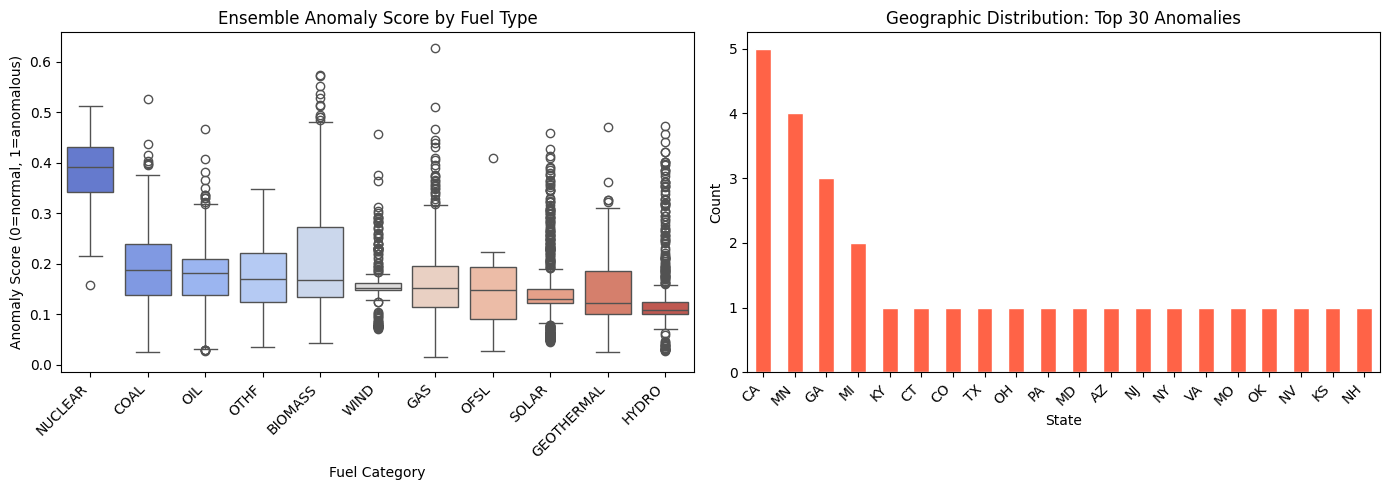

In [16]:
# ── Ensemble score distribution by fuel type ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot by fuel type (seaborn supports order=)
fuel_order = (all_df.groupby('PLFUELCT')['ensemble_score']
              .median().sort_values(ascending=False).index.tolist())
sns.boxplot(data=all_df, x='PLFUELCT', y='ensemble_score',
            order=fuel_order, ax=axes[0], palette='coolwarm')
axes[0].set_title('Ensemble Anomaly Score by Fuel Type')
axes[0].set_xlabel('Fuel Category')
axes[0].set_ylabel('Anomaly Score (0=normal, 1=anomalous)')
plt.setp(axes[0].get_xticklabels(), rotation=45, ha='right')

# Top 30 anomalies by state
if 'PSTATABB' in all_df.columns:
    top30 = all_df.nlargest(30, 'ensemble_score')
    state_counts = top30['PSTATABB'].value_counts()
    state_counts.plot(kind='bar', ax=axes[1], color='tomato', edgecolor='white')
    axes[1].set_title('Geographic Distribution: Top 30 Anomalies')
    axes[1].set_xlabel('State')
    axes[1].set_ylabel('Count')
    plt.setp(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'anomaly_by_fuel_and_state.png', dpi=150)
plt.show()


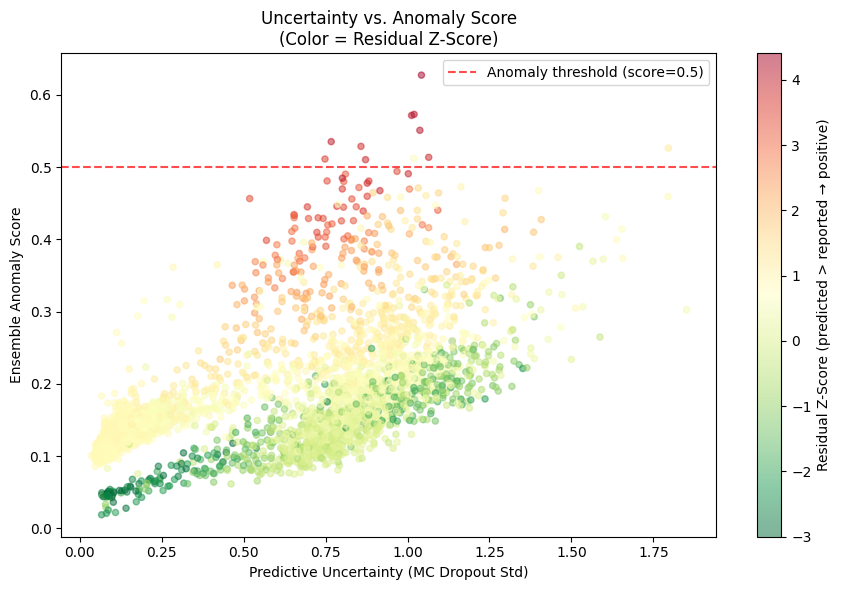

In [17]:
# ── Uncertainty vs Anomaly Score ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(all_df['pred_uncertainty'], all_df['ensemble_score'],
                c=all_df['residual_zscore'].clip(-3, 6), cmap='RdYlGn_r',
                alpha=0.5, s=20)
plt.colorbar(sc, ax=ax, label='Residual Z-Score (predicted > reported → positive)')
ax.axhline(0.5, color='red', linestyle='--', alpha=0.7, label='Anomaly threshold (score=0.5)')
ax.set_xlabel('Predictive Uncertainty (MC Dropout Std)')
ax.set_ylabel('Ensemble Anomaly Score')
ax.set_title('Uncertainty vs. Anomaly Score\n(Color = Residual Z-Score)')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'uncertainty_vs_anomaly_score.png', dpi=150)
plt.show()



=== Anomaly Detection Performance (Proxy Labels: 'suspicious' = positive) ===
AUC-ROC:  0.3741
AUC-PR:   0.0603  (random baseline = 0.0722)


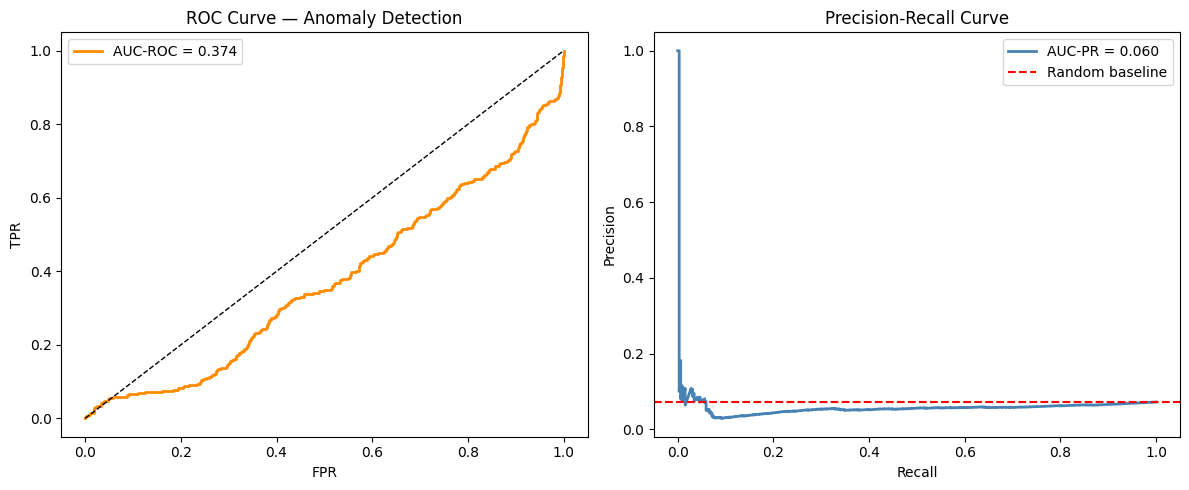

In [18]:
# ── Evaluation: if ground-truth anomaly labels available ────────────────────
# This block computes AUC-PR / AUC-ROC treating 'suspicious' plants as positive class.
# In practice, labels come from regulatory audits or cross-referencing CEMS data.

y_true_proxy = (all_df['verification_status'] == 'suspicious').astype(int).values
y_score      = all_df['ensemble_score'].values

if y_true_proxy.sum() > 0:
    auc_roc = roc_auc_score(y_true_proxy, y_score)
    auc_pr  = average_precision_score(y_true_proxy, y_score)
    print(f"\n=== Anomaly Detection Performance (Proxy Labels: 'suspicious' = positive) ===")
    print(f"AUC-ROC:  {auc_roc:.4f}")
    print(f"AUC-PR:   {auc_pr:.4f}  (random baseline = {y_true_proxy.mean():.4f})")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    fpr, tpr, _ = roc_curve(y_true_proxy, y_score)
    axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC-ROC = {auc_roc:.3f}')
    axes[0].plot([0,1],[0,1], 'k--', lw=1)
    axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
    axes[0].set_title('ROC Curve — Anomaly Detection'); axes[0].legend()

    prec, rec, _ = precision_recall_curve(y_true_proxy, y_score)
    axes[1].plot(rec, prec, color='steelblue', lw=2, label=f'AUC-PR = {auc_pr:.3f}')
    axes[1].axhline(y_true_proxy.mean(), color='red', linestyle='--', label='Random baseline')
    axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall Curve'); axes[1].legend()

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'anomaly_detection_curves.png', dpi=150)
    plt.show()
else:
    print("No suspicious plants in current data — skip ROC/PR evaluation.")


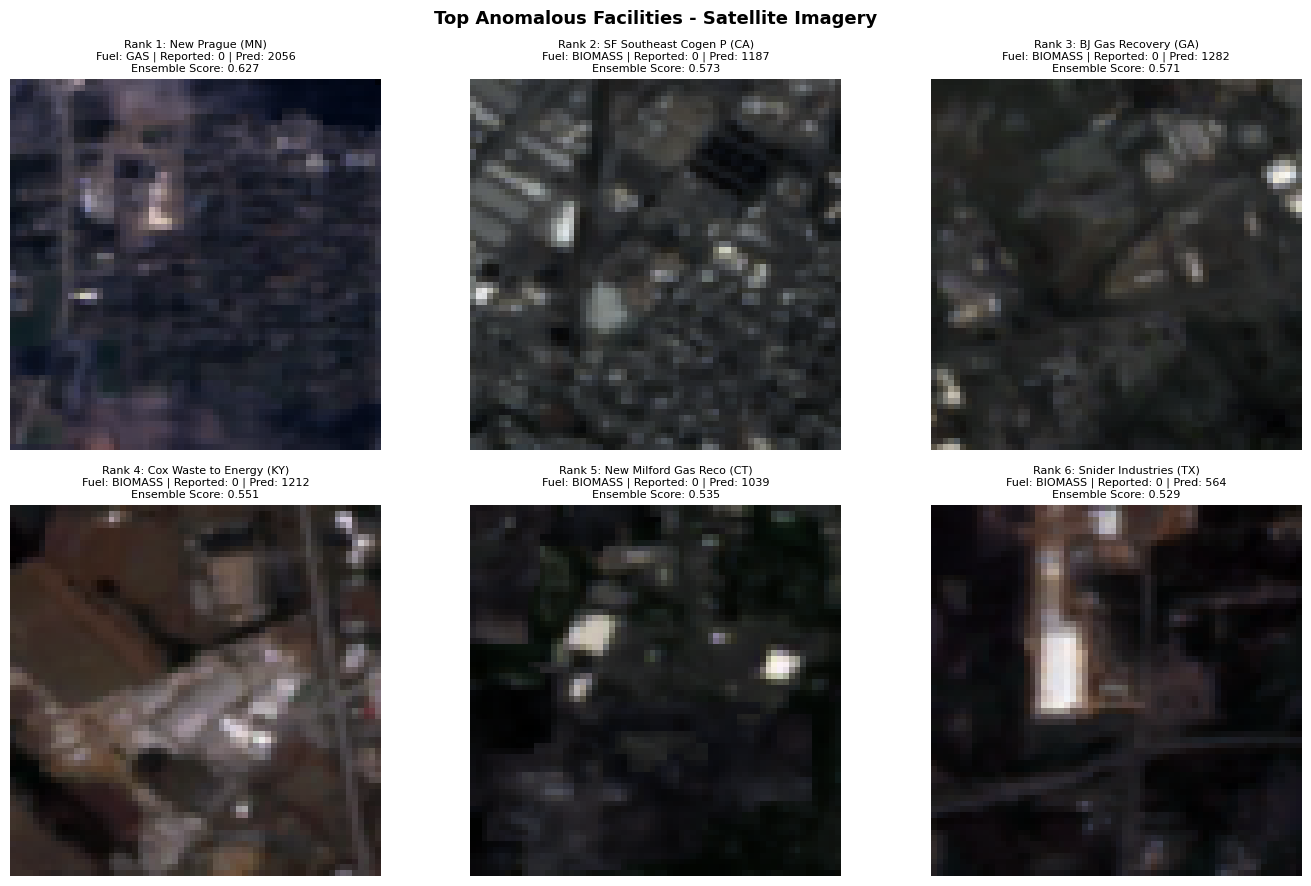

In [19]:
# Inspect top anomalies with their satellite images
top_anomalies = watchlist.head(6)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.ravel()

for i, (rank, row) in enumerate(top_anomalies.iterrows()):
    ax = axes[i]
    match = all_df[all_df['SEQPLT14'] == row['SEQPLT14']] if 'SEQPLT14' in row else pd.DataFrame()
    if len(match) == 0:
        ax.set_title(f'Rank {rank}: No match'); ax.axis('off'); continue
    img_path = match.iloc[0]['img_path']

    img_t = image_cache.get(img_path)
    if img_t is not None:
        img = img_t.numpy().transpose(1, 2, 0)  # (H, W, 3)
        ax.imshow(np.clip(img, 0, 1))
    else:
        ax.set_facecolor('gray')

    name     = row.get('PNAME', 'N/A')
    state    = row.get('PSTATABB', '?')
    fuel     = row.get('PLFUELCT', '?')
    reported = row.get('co2_intensity', float('nan'))
    pred     = row.get('pred_intensity', float('nan'))
    score    = row.get('ensemble_score', float('nan'))
    rep_str  = f'{reported:.0f}' if pd.notna(reported) else 'N/A'
    pred_str = f'{pred:.0f}'     if pd.notna(pred)     else 'N/A'

    ax.set_title(
        f'Rank {rank}: {str(name)[:20]} ({state})\n'
        f'Fuel: {fuel} | Reported: {rep_str} | Pred: {pred_str}\n'
        f'Ensemble Score: {score:.3f}',
        fontsize=8
    )
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor('red'); spine.set_linewidth(3)

plt.suptitle('Top Anomalous Facilities - Satellite Imagery', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top_anomaly_images.png', dpi=150)
plt.show()


## 12. Summary Report

In [20]:
print("=" * 60)
print("ANOMALY DETECTION SUMMARY REPORT")
print("=" * 60)
print(f"Total plants analysed:        {len(all_df)}")
print(f"  Verified (clean records):   {(all_df['verification_status']=='verified').sum()}")
print(f"  Suspicious (fossil+low):    {(all_df['verification_status']=='suspicious').sum()}")
print(f"  Missing CO2 data:           {(all_df['verification_status']=='missing').sum()}")
print()
print(f"Flagged by residual (Z>{RESIDUAL_ZSCORE_THRESH}):  {(all_df['residual_zscore']>RESIDUAL_ZSCORE_THRESH).sum()}")
print(f"Flagged by Isolation Forest:  {all_df['iso_anomaly'].sum()}")
print(f"Flagged by One-Class SVM:     {all_df['svm_anomaly'].sum()}")
print()
print(f"Ensemble top-20 by fuel type:")
print(watchlist.head(20)['PLFUELCT'].value_counts().to_string())
print()
print(f"Output files:")
for f in sorted(OUTPUT_DIR.glob("*")):
    print(f"  {f.name}")
print("=" * 60)


ANOMALY DETECTION SUMMARY REPORT
Total plants analysed:        4435
  Verified (clean records):   1777
  Suspicious (fossil+low):    320
  Missing CO2 data:           2338

Flagged by residual (Z>2.5):  71
Flagged by Isolation Forest:  98
Flagged by One-Class SVM:     1334

Ensemble top-20 by fuel type:
PLFUELCT
BIOMASS    15
GAS         2
NUCLEAR     2
COAL        1

Output files:
  anomaly_by_fuel_and_state.png
  anomaly_detection_curves.png
  anomaly_scatter.png
  anomaly_watchlist.csv
  residual_distribution.png
  top_anomaly_images.png
  uncertainty_vs_anomaly_score.png


## 13. Operationalisation & Next Steps

**Short-term:**
- Cross-reference the watchlist against EPA CAMPD hourly CEMS data to determine whether  
  residuals are explained by operational downtime vs. actual underreporting.
- Filter by *fossil fuel only* for the final regulatory referral list — renewables  
  with high anomaly scores likely reflect model limitations, not fraud.

**Medium-term:**
- Retrain quarterly as new Landsat/Sentinel imagery and updated eGRID data become available.
- Replace the proxy "suspicious" label with ground-truth audit outcomes to move from  
  unsupervised to a semi-supervised anomaly detection framework.

**Long-term:**
- Extend to **international plants** using the Global Power Plant Database (WRI) —  
  the Landsat 8 model generalises globally, unlike NAIP (US only).
- Integrate with **ESG screening platforms** to provide continuous, satellite-derived  
  emissions risk scores for investment portfolios.
